In [1]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


Audio data is the digital representation of sound waves. It is captured by converting analog sound signals (like human speech, music, or environmental noise) into a series of numerical values. This process involves sampling the continuous sound wave at discrete intervals and storing it in formats computers can process. Common audio file formats include:

In [2]:
# Path to your organized audio folder
DATASET_PATH = "../data/audio/ESC-50/organized_audio"

# Select one class folder
class_name = "dog"

# Select first audio file from that class
class_folder = os.path.join(DATASET_PATH, class_name)
audio_file = os.listdir(class_folder)[0]

file_path = os.path.join(class_folder, audio_file)

print("Loading file:", file_path)

Loading file: ../data/audio/ESC-50/organized_audio/dog/2-122104-B-0.wav


In [3]:
# Load audio
audio, sr = librosa.load(file_path, sr=22050)

print("Audio length:", len(audio))
print("Sample rate:", sr)



/workspaces/Omnisense/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio length: 110250
Sample rate: 22050


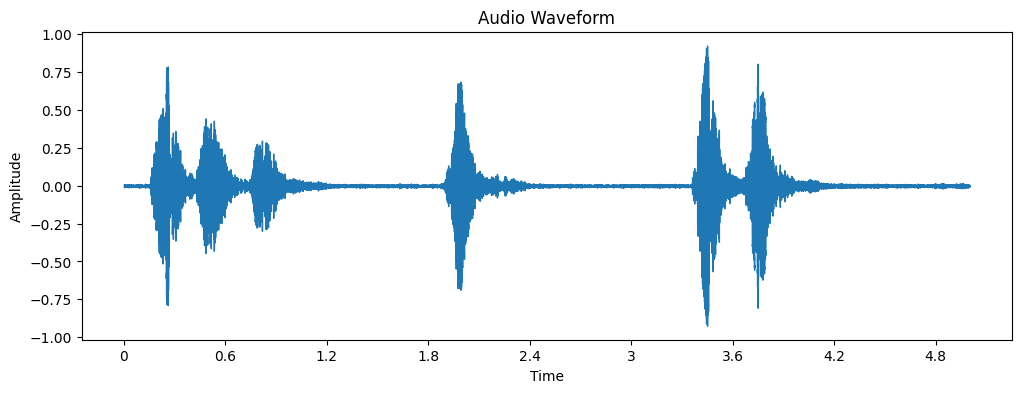

In [4]:
# Generate Mel Spectrogram
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

# Convert to decibel scale
mel_db = librosa.power_to_db(mel, ref=np.max)

# Plot waveform
plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()



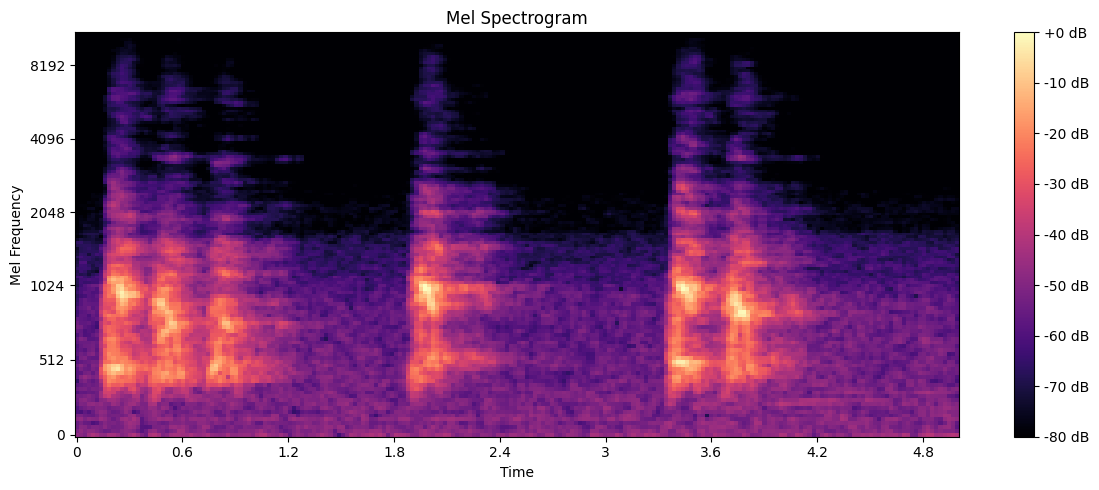

In [5]:
# Plot Mel Spectrogram
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

Bright colors → stronger sound energy

Dark colors → weaker sound

## Generate Spectrogram Dataset

In [6]:
"""import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Turn off interactive mode to prevent kernel crashes
plt.ioff()

# Input dataset path (organized audio)
AUDIO_DATASET = "../data/audio/ESC-50/organized_audio"

# Output spectrogram dataset
OUTPUT_FOLDER = "../data/audio/ESC-50/spectrograms"

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Starting spectrogram generation...")

# Loop through each class
for class_name in os.listdir(AUDIO_DATASET):

    class_path = os.path.join(AUDIO_DATASET, class_name)

    if not os.path.isdir(class_path):
        continue

    print("Processing class:", class_name)

    # Create output class folder
    output_class_folder = os.path.join(OUTPUT_FOLDER, class_name)
    os.makedirs(output_class_folder, exist_ok=True)

    # Loop through audio files
    for audio_file in os.listdir(class_path):

        audio_path = os.path.join(class_path, audio_file)

        try:
            # Load audio
            audio, sr = librosa.load(audio_path, sr=22050)

            # Generate Mel Spectrogram
            mel = librosa.feature.melspectrogram(
                y=audio,
                sr=sr,
                n_mels=128
            )

            mel_db = librosa.power_to_db(mel, ref=np.max)

            # Plot spectrogram
            plt.figure(figsize=(3,3))

            librosa.display.specshow(
                mel_db,
                sr=sr,
                x_axis=None,
                y_axis=None
            )

            plt.axis("off")

            # Save spectrogram image
            file_name = audio_file.replace(".wav", ".png")
            save_path = os.path.join(output_class_folder, file_name)

            plt.savefig(
                save_path,
                bbox_inches="tight",
                pad_inches=0
            )

            plt.close()

        except Exception as e:
            print("Error processing:", audio_file)
            print(e)

print("Spectrogram dataset created successfully!")"""

'import os\nimport librosa\nimport librosa.display\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Turn off interactive mode to prevent kernel crashes\nplt.ioff()\n\n# Input dataset path (organized audio)\nAUDIO_DATASET = "../data/audio/ESC-50/organized_audio"\n\n# Output spectrogram dataset\nOUTPUT_FOLDER = "../data/audio/ESC-50/spectrograms"\n\n# Create output folder if it doesn\'t exist\nos.makedirs(OUTPUT_FOLDER, exist_ok=True)\n\nprint("Starting spectrogram generation...")\n\n# Loop through each class\nfor class_name in os.listdir(AUDIO_DATASET):\n\n    class_path = os.path.join(AUDIO_DATASET, class_name)\n\n    if not os.path.isdir(class_path):\n        continue\n\n    print("Processing class:", class_name)\n\n    # Create output class folder\n    output_class_folder = os.path.join(OUTPUT_FOLDER, class_name)\n    os.makedirs(output_class_folder, exist_ok=True)\n\n    # Loop through audio files\n    for audio_file in os.listdir(class_path):\n\n        audio_path = os.pat

In [7]:
X = []
y = []

labels = sorted(os.listdir(DATASET_PATH))
label_map = {label:i for i,label in enumerate(labels)}

print("\nLabel mapping:", label_map)

for label in labels:

    class_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(class_path):
        continue

    for file in tqdm(os.listdir(class_path)):

        file_path = os.path.join(class_path, file)

        try:
            audio, sr = librosa.load(file_path, sr=22050)

            mel = librosa.feature.melspectrogram(
                y=audio,
                sr=sr,
                n_mels=128
            )

            mel_db = librosa.power_to_db(mel, ref=np.max)

            # ensure fixed size
            if mel_db.shape[1] < 128:
                pad_width = 128 - mel_db.shape[1]
                mel_db = np.pad(mel_db, ((0,0),(0,pad_width)))
            else:
                mel_db = mel_db[:,:128]

            X.append(mel_db)
            y.append(label_map[label])

        except Exception as e:
            print("Error:", file_path)

X = np.array(X)
y = np.array(y)

# CNN expects channel dimension
X = X[..., np.newaxis]

print("Dataset shape:", X.shape)

np.save("data/X_audio.npy", X)
np.save("data/y_audio.npy", y)

print("Feature extraction complete")


Label mapping: {'airplane': 0, 'breathing': 1, 'brushing_teeth': 2, 'can_opening': 3, 'car_horn': 4, 'cat': 5, 'chainsaw': 6, 'chirping_birds': 7, 'church_bells': 8, 'clapping': 9, 'clock_alarm': 10, 'clock_tick': 11, 'coughing': 12, 'cow': 13, 'crackling_fire': 14, 'crickets': 15, 'crow': 16, 'crying_baby': 17, 'dog': 18, 'door_wood_creaks': 19, 'door_wood_knock': 20, 'drinking_sipping': 21, 'engine': 22, 'fireworks': 23, 'footsteps': 24, 'frog': 25, 'glass_breaking': 26, 'hand_saw': 27, 'helicopter': 28, 'hen': 29, 'insects': 30, 'keyboard_typing': 31, 'laughing': 32, 'mouse_click': 33, 'pig': 34, 'pouring_water': 35, 'rain': 36, 'rooster': 37, 'sea_waves': 38, 'sheep': 39, 'siren': 40, 'sneezing': 41, 'snoring': 42, 'thunderstorm': 43, 'toilet_flush': 44, 'train': 45, 'vacuum_cleaner': 46, 'washing_machine': 47, 'water_drops': 48, 'wind': 49}


100%|██████████| 40/40 [00:00<00:00, 76.94it/s]


Dataset shape: (2000, 128, 128, 1)
Feature extraction complete


NEW CODE FILE

In [9]:
import os
import numpy as np
import librosa
import librosa.display
import noisereduce as nr
from tqdm import tqdm

In [10]:
# Dataset path (organized class folders)
DATASET_PATH = "../data/audio/ESC-50/organized_audio"

# Target sampling rate
TARGET_SR = 16000

# Mel spectrogram parameters
N_MELS = 128
MAX_LEN = 128

In [11]:
labels = sorted(os.listdir(DATASET_PATH))
label_map = {label: i for i, label in enumerate(labels)}

print("Total Classes:", len(labels))
print("Label Mapping:", label_map)

Total Classes: 50
Label Mapping: {'airplane': 0, 'breathing': 1, 'brushing_teeth': 2, 'can_opening': 3, 'car_horn': 4, 'cat': 5, 'chainsaw': 6, 'chirping_birds': 7, 'church_bells': 8, 'clapping': 9, 'clock_alarm': 10, 'clock_tick': 11, 'coughing': 12, 'cow': 13, 'crackling_fire': 14, 'crickets': 15, 'crow': 16, 'crying_baby': 17, 'dog': 18, 'door_wood_creaks': 19, 'door_wood_knock': 20, 'drinking_sipping': 21, 'engine': 22, 'fireworks': 23, 'footsteps': 24, 'frog': 25, 'glass_breaking': 26, 'hand_saw': 27, 'helicopter': 28, 'hen': 29, 'insects': 30, 'keyboard_typing': 31, 'laughing': 32, 'mouse_click': 33, 'pig': 34, 'pouring_water': 35, 'rain': 36, 'rooster': 37, 'sea_waves': 38, 'sheep': 39, 'siren': 40, 'sneezing': 41, 'snoring': 42, 'thunderstorm': 43, 'toilet_flush': 44, 'train': 45, 'vacuum_cleaner': 46, 'washing_machine': 47, 'water_drops': 48, 'wind': 49}


In [12]:
X = []
y = []

In [13]:
for label in labels:
    
    class_path = os.path.join(DATASET_PATH, label)
    
    if not os.path.isdir(class_path):
        continue
        
    print(f"Processing class: {label}")
    
    for file in tqdm(os.listdir(class_path)):
        
        file_path = os.path.join(class_path, file)
        
        try:
            # Load audio
            audio, sr = librosa.load(file_path, sr=None)
            
            # --------------------
            # Resample Audio
            # --------------------
            if sr != TARGET_SR:
                audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)
                sr = TARGET_SR
            
            # --------------------
            # Noise Reduction
            # --------------------
            audio = nr.reduce_noise(y=audio, sr=sr)
            
            # --------------------
            # Normalize Audio
            # --------------------
            audio = librosa.util.normalize(audio)
            
            # --------------------
            # Generate Mel Spectrogram
            # --------------------
            mel = librosa.feature.melspectrogram(
                y=audio,
                sr=sr,
                n_mels=N_MELS
            )
            
            mel_db = librosa.power_to_db(mel, ref=np.max)
            
            # --------------------
            # Fix Spectrogram Size
            # --------------------
            if mel_db.shape[1] < MAX_LEN:
                pad_width = MAX_LEN - mel_db.shape[1]
                mel_db = np.pad(mel_db, ((0,0),(0,pad_width)))
            else:
                mel_db = mel_db[:, :MAX_LEN]
            
            # Store data
            X.append(mel_db)
            y.append(label_map[label])
        
        except Exception as e:
            print("Error processing:", file_path)

Processing class: airplane


100%|██████████| 40/40 [00:02<00:00, 13.58it/s]


Processing class: breathing


100%|██████████| 40/40 [00:02<00:00, 15.17it/s]


Processing class: brushing_teeth


...

100%|██████████| 40/40 [00:02<00:00, 14.69it/s]


Processing class: water_drops


100%|██████████| 40/40 [00:02<00:00, 14.96it/s]


Processing class: wind


100%|██████████| 40/40 [00:02<00:00, 15.22it/s]


In [ ]:
X = np.array(X)
y = np.array(y)

# Add channel dimension for CNN
X = X[..., np.newaxis]

print("Feature dataset shape:", X.shape)
print("Label dataset shape:", y.shape)

In [ ]:
np.save("X_audio.npy", X)
np.save("y_audio.npy", y)

print("Preprocessed dataset saved successfully.")

for one audio file

In [15]:
# Path to your organized audio folder
DATASET_PATH = "../data/audio/ESC-50/organized_audio"

# Select one class folder
class_name = "dog"

# Select first audio file from that class
class_folder = os.path.join(DATASET_PATH, class_name)
audio_file = os.listdir(class_folder)[0]

file_path = os.path.join(class_folder, audio_file)

print("Loading file:", file_path)

Loading file: ../data/audio/ESC-50/organized_audio/dog/2-122104-B-0.wav


In [17]:
y, sr = librosa.load(file_path, sr=None)

print("Sample Rate:", sr)
print("Audio Length:", len(y))

Sample Rate: 44100
Audio Length: 220500


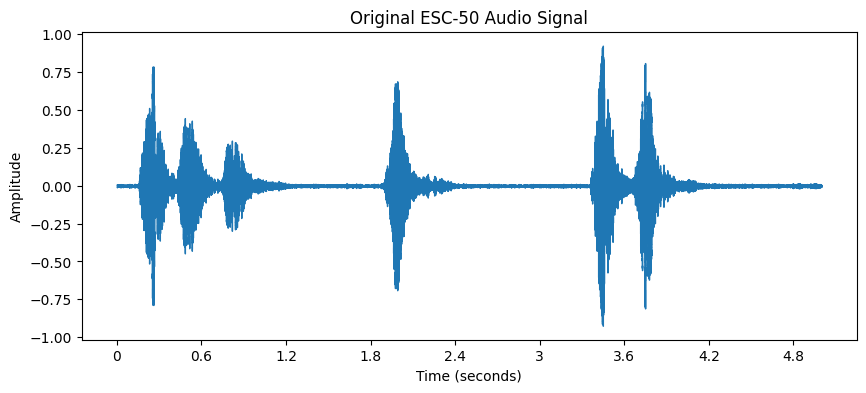

In [18]:
plt.figure(figsize=(10,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Original ESC-50 Audio Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

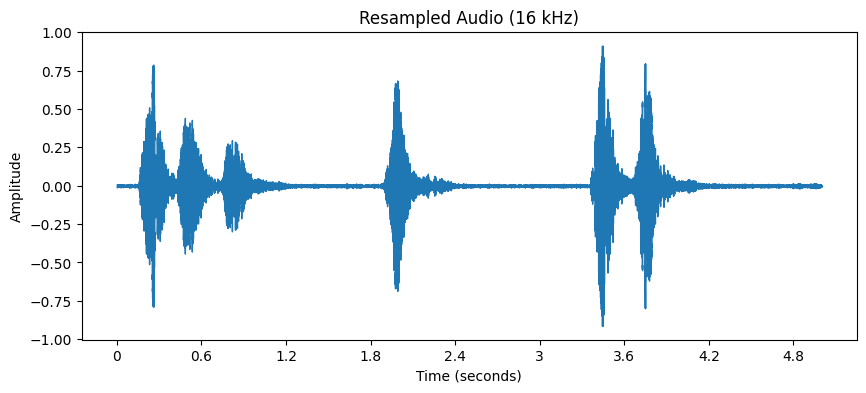

In [19]:
target_sr = 16000

y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

plt.figure(figsize=(10,4))

librosa.display.waveshow(y_resampled, sr=target_sr)

plt.title("Resampled Audio (16 kHz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

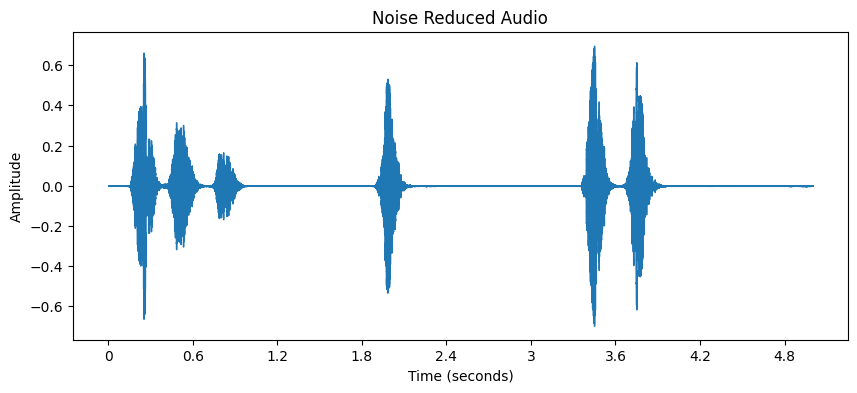

In [20]:
y_denoised = nr.reduce_noise(y=y_resampled, sr=target_sr)

plt.figure(figsize=(10,4))

librosa.display.waveshow(y_denoised, sr=target_sr)

plt.title("Noise Reduced Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

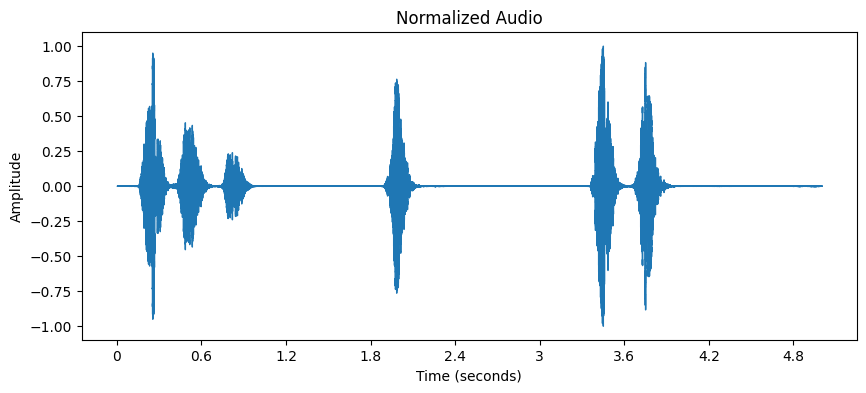

In [21]:
y_normalized = librosa.util.normalize(y_denoised)

plt.figure(figsize=(10,4))

librosa.display.waveshow(y_normalized, sr=target_sr)

plt.title("Normalized Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

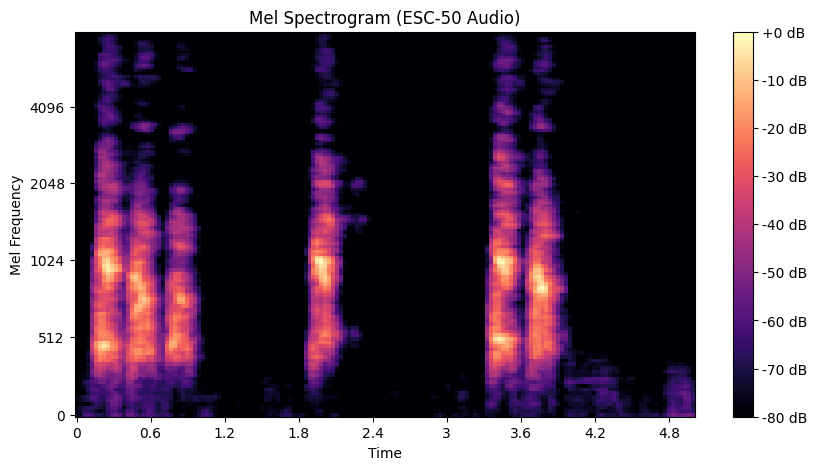

In [22]:
mel_spec = librosa.feature.melspectrogram(
    y=y_normalized,
    sr=target_sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10,5))

librosa.display.specshow(
    mel_db,
    sr=target_sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Mel Spectrogram (ESC-50 Audio)")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()